Fit model to data. 

Add an extra event that was originally not analysed, and removing two that were reclassified:

Add: HsaEX1046522 from the ABI2 gene and the PSI values in GFP, CONT, LOW, MID, HIGH are 0, 2.28, 20.47, 74.85, 83.45.

Remove:
remove the events HsaEX0051111 and HsaEX1003606 from this category (I reclassified them as NonResponding)



In [1]:
import deap
from deap import base
from deap import creator
from deap import tools
from deap import algorithms
from functools import partial
import random, sys

import sympy
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.optimize import minimize
import seaborn as sns
import copy

sys.path.append("/Users/rosamartinezcorral/OneDrive - CRG - Centre de Regulacio Genomica/papers/github_repos/SRRM4_MapSy_2024")
import auxfuncs_fitting
from collections import OrderedDict

In [2]:
remove=["HsaEX0051111", "HsaEX1003606"]

Even if I only want to fit to a few subcategories here, load everything in case we want to change this.

# Get the data (minigene library)

In [3]:
#for each subcategory, I want a dataframe of the LS, with 4 columns: GFP, LOW, MID, HIGH, and the HS, with 4 columns: GFP, LOW, MID, HIGH
#So if we have n subcategories, we end up with 2*n dataframes

categories_fit_HSLS=['WT','U1cons_a','U1cons_b','U6cons','GTtoGC5ss', 'BP_stg1', 'BP_weak3', 'Py-stg3','Py-weak3','BP_stg1;Py-stg3','BP_weak3;Py-weak3','BP_stg1;Py-stg3;U1cons','-ESS2-3','-ESE2-5']


dfind=pd.read_csv("./2024_07_04_HSLStofit.csv",sep="\t",index_col=0)
display(dfind.head())

,VARIANT,gene_or_species,event,mutation,Subcat,GFP,LOW,MID,HIGH,final_tier
0,ABI1-HsaEX0000641-U1cons,ABI1,HsaEX0000641,-U1cons,U1cons_a,9.40,8.64,43.48,95.09,HS
1,ABI1-HsaEX0000641-U6cons,ABI1,HsaEX0000641,-U6cons,U6cons,16.24,16.11,45.80,97.37,HS
2,ABI1-HsaEX0000641-WT,ABI1,HsaEX0000641,-WT,WT,2.70,5.39,32.39,92.30,HS
3,ACVR2A-HsaEX0002213-U1cons,ACVR2A,HsaEX0002213,-U1cons,U1cons_a,3.79,4.99,38.16,92.12,LS
4,ACVR2A-HsaEX0002213-U6cons,ACVR2A,HsaEX0002213,-U6cons,U6cons,5.13,7.89,40.64,95.18,LS


In [4]:
dfind[dfind["event"].isin(remove)]

,VARIANT,gene_or_species,event,mutation,Subcat,GFP,LOW,MID,HIGH,final_tier


In [5]:
np.unique(sorted(dfind["event"].values))

array(['HsaEX0000641', 'HsaEX0002213', 'HsaEX0012545', 'HsaEX0015276',
       'HsaEX0015478', 'HsaEX0016976', 'HsaEX0018777', 'HsaEX0026467',
       'HsaEX0027672', 'HsaEX0032608', 'HsaEX0034483', 'HsaEX0035450',
       'HsaEX0037213', 'HsaEX0038690', 'HsaEX0038702', 'HsaEX0039034',
       'HsaEX0040386', 'HsaEX0043752', 'HsaEX0044638', 'HsaEX0047035',
       'HsaEX0048492', 'HsaEX0049811', 'HsaEX0051317', 'HsaEX0057701',
       'HsaEX0058030', 'HsaEX0063374', 'HsaEX0063412', 'HsaEX0064198',
       'HsaEX0067208', 'HsaEX1019114', 'HsaEX1026556'], dtype='<U12')

In [6]:
desired_order=categories_fit_HSLS

inputcols=["GFP","LOW","MID","HIGH"]
individual_subdf_minigene=[]
for group in desired_order:
    if group=="WT":
        namecat="WTminigene"
    else:
        namecat=group
    for subgroup in ["LS","HS"]:
        subdf=dfind[(dfind["Subcat"]==group)&(dfind["final_tier"]==subgroup)].copy()
        #in case each event is repeated multiple times, average
        subdf=subdf.groupby(["event"])[inputcols].mean()
        newcolnames=[namecat+"-"+subgroup+":"+x for x in inputcols]
        subdf.columns=newcolnames
        display(subdf.head())
        individual_subdf_minigene.append(subdf)
        
        

,WTminigene-LS:GFP,WTminigene-LS:LOW,WTminigene-LS:MID,WTminigene-LS:HIGH
event,,,,
HsaEX0002213,2.3000,9.5675,52.7325,95.7950
HsaEX0015276,0.4075,2.1975,32.9325,84.7300
HsaEX0015478,1.1850,0.8950,8.1450,59.3175
HsaEX0027672,0.0200,1.0500,12.2000,71.7500
HsaEX0032608,0.0175,0.1825,6.2050,52.5400


,WTminigene-HS:GFP,WTminigene-HS:LOW,WTminigene-HS:MID,WTminigene-HS:HIGH
event,,,,
HsaEX0000641,2.8450,7.2850,43.1275,93.3225
HsaEX0012545,0.2025,2.1975,29.4400,87.4275
HsaEX0016976,1.2525,7.2550,42.1825,90.7075
HsaEX0018777,3.1775,4.6425,36.6000,89.6625
HsaEX0026467,8.7350,18.3425,46.1025,91.1475


,U1cons_a-LS:GFP,U1cons_a-LS:LOW,U1cons_a-LS:MID,U1cons_a-LS:HIGH
event,,,,
HsaEX0002213,3.79,4.99,38.16,92.12
HsaEX0015276,0.84,2.14,31.80,92.84
HsaEX0015478,5.28,5.62,32.55,94.89
HsaEX0027672,NaN,NaN,NaN,NaN
HsaEX0032608,0.13,0.13,7.33,71.18


,U1cons_a-HS:GFP,U1cons_a-HS:LOW,U1cons_a-HS:MID,U1cons_a-HS:HIGH
event,,,,
HsaEX0000641,9.40,8.64,43.48,95.09
HsaEX0012545,7.32,27.58,61.52,96.94
HsaEX0016976,48.36,71.52,81.26,96.57
HsaEX0018777,8.11,11.71,42.31,93.28
HsaEX0026467,43.11,62.24,74.02,97.32


,U1cons_b-LS:GFP,U1cons_b-LS:LOW,U1cons_b-LS:MID,U1cons_b-LS:HIGH
event,,,,
HsaEX0002213,8.28,30.54,72.71,96.51
HsaEX0015276,1.37,7.13,53.45,94.62
HsaEX0015478,11.71,15.39,61.78,96.29
HsaEX0027672,27.00,39.88,73.60,97.19
HsaEX0032608,0.19,0.83,14.32,68.47


...

,BP_stg1;Py-stg3;U1cons-HS:GFP,BP_stg1;Py-stg3;U1cons-HS:LOW,BP_stg1;Py-stg3;U1cons-HS:MID,BP_stg1;Py-stg3;U1cons-HS:HIGH
event,,,,
HsaEX0000641,90.03,96.56,97.73,98.79
HsaEX0012545,84.38,93.97,96.80,98.91
HsaEX0016976,98.27,99.05,99.32,99.50
HsaEX0018777,96.46,97.69,98.71,99.23
HsaEX0026467,80.98,86.37,91.41,97.75


,-ESS2-3-LS:GFP,-ESS2-3-LS:LOW,-ESS2-3-LS:MID,-ESS2-3-LS:HIGH
event,,,,
HsaEX0002213,0.18,2.52,26.94,82.91
HsaEX0015276,0.65,0.00,6.70,33.14
HsaEX0015478,0.08,0.00,0.13,0.96
HsaEX0027672,0.00,0.00,1.37,4.24
HsaEX0032608,0.00,0.00,0.35,3.48


,-ESS2-3-HS:GFP,-ESS2-3-HS:LOW,-ESS2-3-HS:MID,-ESS2-3-HS:HIGH
event,,,,
HsaEX0000641,0.46,3.47,32.72,83.34
HsaEX0012545,0.00,1.66,17.75,67.01
HsaEX0016976,0.00,0.00,0.10,0.16
HsaEX0018777,0.09,0.05,1.29,7.83
HsaEX0026467,28.21,34.53,60.34,92.23


,-ESE2-5-LS:GFP,-ESE2-5-LS:LOW,-ESE2-5-LS:MID,-ESE2-5-LS:HIGH
event,,,,
HsaEX0002213,29.44,35.67,65.35,94.10
HsaEX0015276,8.71,28.22,66.96,96.01
HsaEX0015478,35.68,47.68,71.09,96.78
HsaEX0027672,0.00,0.00,27.84,66.67
HsaEX0032608,0.00,2.77,42.74,92.74


,-ESE2-5-HS:GFP,-ESE2-5-HS:LOW,-ESE2-5-HS:MID,-ESE2-5-HS:HIGH
event,,,,
HsaEX0000641,64.58,91.01,96.67,98.50
HsaEX0012545,6.25,31.65,70.86,97.70
HsaEX0016976,14.96,28.35,65.87,94.16
HsaEX0018777,58.46,69.76,81.61,97.42
HsaEX0026467,73.33,86.97,89.31,88.69


(28, 4)


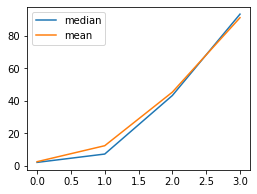

In [7]:
mediandata_minigene=np.asarray([np.nanmedian(x.values,axis=0) for x in individual_subdf_minigene]) #WT-minigene-LS, WT-minigene-HS, Py-weak1-LS,...
print(mediandata_minigene.shape)

meandata_minigene=np.asarray([np.nanmean(x.values,axis=0) for x in individual_subdf_minigene]) #WT-minigene-LS, WT-minigene-HS, Py-weak1-LS,...
plt.figure(figsize=(4,3))
plt.plot(mediandata_minigene[1],label="median")
plt.plot(meandata_minigene[1],label="mean")
plt.legend()
plt.show()

# Now load endogenous data

In [8]:
[x for x in subdf.columns]

['-ESE2-5-HS:GFP', '-ESE2-5-HS:LOW', '-ESE2-5-HS:MID', '-ESE2-5-HS:HIGH']

In [9]:
file2="./2024_04_21_data/ENDO_FOR_ROSA.xlsx"
df_endodata_=pd.read_excel(file2)
display(df_endodata_.head())
df_endodata_=df_endodata_[["EVENT","HEK_GFP","HEK_CTR","HEK_LOW","HEK_MID","HEK_HIGH","tier"]]
display(df_endodata_.head())

,EVENT,HEK_GFP,HEK_CTR,HEK_HIGH,HEK_LOW,HEK_MID,CL_HeLa_GFP_CONT,CL_HeLa_SRRM3_CONT,CL_HeLa_SRRM3_HIGH,CL_HeLa_SRRM3_MID,tier
0,HsaEX0042009,0.32,15.33,97.70,56.15,95.77,0.00,83.41,98.17,96.67,HS
1,HsaEX0041746,21.54,39.59,90.26,75.02,87.50,7.90,30.02,77.78,59.29,HS
2,HsaEX0017556,18.49,32.96,97.60,65.08,95.74,6.55,44.14,98.01,89.73,HS
3,HsaEX0041193,60.26,93.33,100.00,98.87,100.00,58.01,98.87,100.00,98.81,HS
4,HsaEX0061551,11.94,39.45,97.56,62.93,94.59,2.38,26.84,95.16,70.35,HS


,EVENT,HEK_GFP,HEK_CTR,HEK_LOW,HEK_MID,HEK_HIGH,tier
0,HsaEX0042009,0.32,15.33,56.15,95.77,97.70,HS
1,HsaEX0041746,21.54,39.59,75.02,87.50,90.26,HS
2,HsaEX0017556,18.49,32.96,65.08,95.74,97.60,HS
3,HsaEX0041193,60.26,93.33,98.87,100.00,100.00,HS
4,HsaEX0061551,11.94,39.45,62.93,94.59,97.56,HS


In [10]:
print(len(df_endodata_))
df_endodata_=df_endodata_[~df_endodata_["EVENT"].isin(remove)]
print(len(df_endodata_))

145
143


In [12]:
new_LS_event=[0, 2.28, 20.47, 74.85, 83.45]

individual_subdf_endo=[]
for tier in ["LS","HS"]:
    subdf=df_endodata_[df_endodata_["tier"]==tier][["HEK_GFP","HEK_CTR","HEK_LOW","HEK_MID","HEK_HIGH"]]
    newnames=["WTendo-%s:%s"%(tier,x.split("_")[1]) for x in subdf.columns]
    newnames={subdf.columns[i]:newnames[i] for i in range(len(subdf.columns))}
    print(newnames)
    print(len(subdf.columns))
    subdf=subdf.rename(columns=newnames)
    print(len(subdf))
    print(subdf.head())
    if tier=="LS":
        #add here the new low sensitive
        new_LS_subdf={list(newnames.values())[i]:new_LS_event[i] for i in range(5)}
        subdf = subdf._append(new_LS_subdf, ignore_index = True)
    print(len(subdf))
    print(subdf.head())
    individual_subdf_endo.append(subdf)

{'HEK_GFP': 'WTendo-LS:GFP', 'HEK_CTR': 'WTendo-LS:CTR', 'HEK_LOW': 'WTendo-LS:LOW', 'HEK_MID': 'WTendo-LS:MID', 'HEK_HIGH': 'WTendo-LS:HIGH'}
5
70
    WTendo-LS:GFP  WTendo-LS:CTR  WTendo-LS:LOW  WTendo-LS:MID  WTendo-LS:HIGH
73          53.08          58.01          76.75          92.53           92.58
74           0.00           3.02           4.42           4.92            1.97
75           1.09           3.79          18.83          34.65           46.99
76          45.16          24.22          28.04          44.30           60.69
77           1.04           0.00          20.68          71.99           83.75
71
   WTendo-LS:GFP  WTendo-LS:CTR  WTendo-LS:LOW  WTendo-LS:MID  WTendo-LS:HIGH
0          53.08          58.01          76.75          92.53           92.58
1           0.00           3.02           4.42           4.92            1.97
2           1.09           3.79          18.83          34.65           46.99
3          45.16          24.22          28.04          44.30  

In [13]:
median_endo=[x.median() for x in individual_subdf_endo]
print(median_endo)
mediandata_endo=[x.values for x in median_endo]

mean_endo=[x.mean() for x in individual_subdf_endo]
print(mean_endo)
meandata_endo=[x.values for x in mean_endo]

[WTendo-LS:GFP      0.00
WTendo-LS:CTR      0.93
WTendo-LS:LOW      7.37
WTendo-LS:MID     31.68
WTendo-LS:HIGH    46.99
dtype: float64, WTendo-HS:GFP      0.47
WTendo-HS:CTR     16.67
WTendo-HS:LOW     58.14
WTendo-HS:MID     91.56
WTendo-HS:HIGH    94.25
dtype: float64]
[WTendo-LS:GFP      4.999296
WTendo-LS:CTR      5.820141
WTendo-LS:LOW     14.508592
WTendo-LS:MID     38.861268
WTendo-LS:HIGH    48.728169
dtype: float64, WTendo-HS:GFP      8.082055
WTendo-HS:CTR     23.445068
WTendo-HS:LOW     55.584110
WTendo-HS:MID     87.643014
WTendo-HS:HIGH    91.382603
dtype: float64]


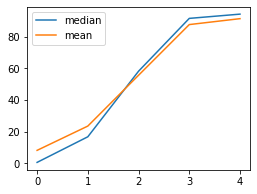

In [14]:
plt.figure(figsize=(4,3))
plt.plot(mediandata_endo[1],label="median")
plt.plot(meandata_endo[1],label="mean")
plt.legend()
plt.show()

# Now load the WT CS, and average them all 

In [15]:
CS_keep_mut=pd.read_csv("./2024_07_01_CSwmuttofit.csv",sep="\t",index_col=0)
inputcols=["GFP","LOW","MID","HIGH"]
individual_subdf_CS=[]
for group in ["WT","U1cons","BP_stg1","BP_weak3","Py-weak3"]:
    if group=="WT":
        namecat="WTCSrem"
    else:
        namecat="CSrem-"+group
    
    subdf=CS_keep_mut[CS_keep_mut["Subcat"]==group].copy()
    #in case each event is repeated multiple times, average
    subdf=subdf.groupby("event")[inputcols].mean()
    newcolnames=[namecat+":"+x for x in inputcols]
    subdf.columns=newcolnames
    display(subdf.head())
    individual_subdf_CS.append(subdf)

,WTCSrem:GFP,WTCSrem:LOW,WTCSrem:MID,WTCSrem:HIGH
event,,,,
HsaEX1038166,7.305,12.620,48.130,90.400
HsaEX6024969,14.885,18.065,38.810,78.080
HsaEX6040016,7.320,10.220,22.665,55.015
HsaEX6077184,29.220,30.765,47.295,83.740
HsaEX6093676,41.290,45.240,46.065,60.030


,CSrem-U1cons:GFP,CSrem-U1cons:LOW,CSrem-U1cons:MID,CSrem-U1cons:HIGH
event,,,,
HsaEX1038166,90.94,94.03,96.65,98.65
HsaEX6024969,15.74,19.15,42.50,83.15
HsaEX6040016,6.98,7.77,19.35,52.21
HsaEX6077184,45.26,43.83,62.69,91.07
HsaEX6093676,40.81,45.68,46.67,61.43


,CSrem-BP_stg1:GFP,CSrem-BP_stg1:LOW,CSrem-BP_stg1:MID,CSrem-BP_stg1:HIGH
event,,,,
HsaEX1038166,28.93,42.62,71.67,95.21
HsaEX6024969,94.39,96.40,97.68,99.31
HsaEX6040016,11.33,13.92,32.47,67.57
HsaEX6077184,94.23,93.79,96.00,98.06
HsaEX6093676,93.02,93.28,93.12,95.76


,CSrem-BP_weak3:GFP,CSrem-BP_weak3:LOW,CSrem-BP_weak3:MID,CSrem-BP_weak3:HIGH
event,,,,
HsaEX1038166,11.61,22.07,57.27,92.37
HsaEX6024969,4.55,3.68,16.86,52.44
HsaEX6040016,0.75,0.78,1.00,4.00
HsaEX6077184,1.67,1.34,1.83,7.96
HsaEX6093676,0.92,1.05,1.08,1.40


,CSrem-Py-weak3:GFP,CSrem-Py-weak3:LOW,CSrem-Py-weak3:MID,CSrem-Py-weak3:HIGH
event,,,,
HsaEX1038166,0.00,0.08,0.52,0.41
HsaEX6024969,5.33,2.20,6.61,7.36
HsaEX6040016,0.00,0.00,0.00,0.00
HsaEX6077184,0.37,0.00,0.00,0.79
HsaEX6093676,0.49,0.91,1.00,1.16


In [16]:
mediandata_CS=np.asarray([np.nanmedian(x.values,axis=0) for x in individual_subdf_CS]) #WT-minigene-LS, WT-minigene-HS, Py-weak1-LS,...
print(mediandata_CS.shape)



(5, 4)


In [17]:
groups_minigene=[x.columns[0].split(":")[0] for x in individual_subdf_minigene]
groups_minigene

['WTminigene-LS',
 'WTminigene-HS',
 'U1cons_a-LS',
 'U1cons_a-HS',
 'U1cons_b-LS',
 'U1cons_b-HS',
 'U6cons-LS',
 'U6cons-HS',
 'GTtoGC5ss-LS',
 'GTtoGC5ss-HS',
 'BP_stg1-LS',
 'BP_stg1-HS',
 'BP_weak3-LS',
 'BP_weak3-HS',
 'Py-stg3-LS',
 'Py-stg3-HS',
 'Py-weak3-LS',
 'Py-weak3-HS',
 'BP_stg1;Py-stg3-LS',
 'BP_stg1;Py-stg3-HS',
 'BP_weak3;Py-weak3-LS',
 'BP_weak3;Py-weak3-HS',
 'BP_stg1;Py-stg3;U1cons-LS',
 'BP_stg1;Py-stg3;U1cons-HS',
 '-ESS2-3-LS',
 '-ESS2-3-HS',
 '-ESE2-5-LS',
 '-ESE2-5-HS']

In [18]:
groups_endoWT=[x.columns[0].split(":")[0] for x in individual_subdf_endo]
groups_endoWT

['WTendo-LS', 'WTendo-HS']

In [19]:
groups_CS=[x.columns[0].split(":")[0] for x in individual_subdf_CS]
groups_CS

['WTCSrem',
 'CSrem-U1cons',
 'CSrem-BP_stg1',
 'CSrem-BP_weak3',
 'CSrem-Py-weak3']

# Fit only WT, U1 cons, BP_stg1, BP_weak3

In [49]:
groups_tofit=['WTendo-LS','WTendo-HS','WTminigene-LS','WTminigene-HS','U1cons_b-LS','U1cons_b-HS','BP_stg1-LS','BP_stg1-HS','BP_weak3-LS',
 'BP_weak3-HS']
allgroups=groups_endoWT+groups_minigene+groups_CS
allindividual=individual_subdf_endo+individual_subdf_minigene+individual_subdf_CS
meandata=[x for x in meandata_endo]+[x for x in meandata_minigene]+[x for x in meandata_CS]
allgroups_subset=[]
mediandata_subset=[]
allindividual_subset=[]
data=dict()
for i in range(len(allgroups)):
    group=allgroups[i]
    if group in groups_tofit:
        allgroups_subset.append(group)
        allindividual_subset.append(allindividual[i])
        mediandata_subset.append(meandata[i])
        data[group]=list(meandata[i])
allgroups_subset

['WTendo-LS',
 'WTendo-HS',
 'WTminigene-LS',
 'WTminigene-HS',
 'U1cons_b-LS',
 'U1cons_b-HS',
 'BP_stg1-LS',
 'BP_stg1-HS',
 'BP_weak3-LS',
 'BP_weak3-HS']

In [50]:
import json

In [51]:
data

{'WTendo-LS': [4.999295774647886,
  5.820140845070423,
  14.508591549295772,
  38.8612676056338,
  48.7281690140845],
 'WTendo-HS': [8.082054794520548,
  23.445068493150686,
  55.58410958904109,
  87.64301369863013,
  91.38260273972602],
 'WTminigene-LS': [0.5792187499999999,
  1.3765625000000004,
  11.984375,
  51.15375],
 'WTminigene-HS': [2.5885000000000007,
  12.413000000000002,
  45.361000000000004,
  91.13749999999999],
 'U1cons_b-LS': [11.808750000000002,
  19.375625,
  50.46374999999999,
  86.64562500000001],
 'U1cons_b-HS': [16.973333333333333,
  41.367333333333335,
  70.38933333333333,
  95.03933333333333],
 'BP_stg1-LS': [3.5612500000000002,
  8.075624999999999,
  28.238750000000003,
  65.845],
 'BP_stg1-HS': [28.74,
  48.27866666666667,
  72.43466666666667,
  95.09866666666669],
 'BP_weak3-LS': [0.29187499999999994,
  0.35374999999999995,
  2.236875,
  9.940624999999999],
 'BP_weak3-HS': [1.6260000000000001,
  6.209333333333333,
  21.280666666666665,
  46.266000000000005]}

In [52]:
#done also for meadian
with open('subsetdata_mean.json', 'w') as f:
    json.dump(data, f)

In [59]:
import os

In [60]:
os.mkdir("individual_subset_data")

In [66]:
for df in allindividual_subset:
    label=df.columns[0].strip(":GFP")
    df.to_csv(os.path.join("individual_subset_data","%s.csv"%label),sep=",",index=False)
    print(label)

WTendo-LS
WTendo-HS
WTminigene-LS
WTminigene-HS
U1cons_b-LS
U1cons_b-HS
BP_stg1-LS
BP_stg1-HS
BP_weak3-LS
BP_weak3-HS


In [53]:
with open('subsetdata_individaul.json', 'w') as f:
    json.dump(data, f)

[    WTendo-LS:GFP  WTendo-LS:CTR  WTendo-LS:LOW  WTendo-LS:MID  WTendo-LS:HIGH
 0           53.08          58.01          76.75          92.53           92.58
 1            0.00           3.02           4.42           4.92            1.97
 2            1.09           3.79          18.83          34.65           46.99
 3           45.16          24.22          28.04          44.30           60.69
 4            1.04           0.00          20.68          71.99           83.75
 ..            ...            ...            ...            ...             ...
 66          45.51          56.61          69.09          95.82           98.48
 67           0.88          11.98           3.24          24.70           19.75
 68           1.42           0.00           5.89          20.36           38.50
 69           0.00           0.00           2.05          12.63           16.44
 70           0.00           2.28          20.47          74.85           83.45
 
 [71 rows x 5 columns],
     WTendo-HS